# plot performance bar charts for paper!


In [39]:
#imports libraries
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
import math
import warnings
warnings.filterwarnings('ignore')

In [40]:
def get_property(filename,prop,method):
    # print(filename)
    values_list=[]
    with open(filename,'r') as file:
        for line in file:
            if method=='TB' and prop=='GStencils/s':
                if ('[STENCIL MSG]:Total:' in line) and ('[STENCIL MSG]:Speed info:' in previous_line):
                    pattern = r'\[STENCIL MSG\]:Total:\s*([\d.]+)\s*GStencils/s'
                    match=re.search(pattern,line)
                    if match:
                        number = match.group(1)
                        val=float(number)
                    else:
                        val=math.nan
                    values_list.append(val)
            if method=='SB' and prop=='GStencils/s':
                if ('[STENCIL MSG]:PropSpeed:' in line): # sb time
                    pattern = r'\[STENCIL MSG\]:PropSpeed:\s*([\d.]+)\s*GStencils/s'
                    match = re.search(pattern,line)
                    if match:
                        number = match.group(1)
                        val=float(number)
                    else:
                        val=math.nan
                    values_list.append(val)
            previous_line=line
    if 'val' not in locals():
        last_val=math.nan
    else:
        last_val=values_list[-1]
    return last_val
def get_datalist(root_folder,order,grids,metric,fix_bug=False):
    data_list=[]
    for counter,grid in enumerate(grids):
        metric_tmp=metric
        p_sb_abc=get_property(os.path.join(root_folder,'log-SB'+order+'-abc'+grid+'.log'),metric_tmp,method='SB')
        p_tb_abc=get_property(os.path.join(root_folder,'log-TB'+order+'-abc'+grid+'.log'),metric_tmp,method='TB')
        data_list.append([p_sb_abc,p_tb_abc])
    return data_list

In [41]:
title_shaheen='SB versus MWD modeling phase on the dual-socket 16-core Intel Haswell System @2.3GHz.'
title_kanary='SB versus MWD modeling phase on the dual-socket 128-core AMD Epyc Rome System @2.0GHz.'
title_milan='SB versus MWD modeling phase on the dual-socket 128-core AMD 7763 system.'
title_milanx='SB versus MWD modeling phase on the dual-socket 128-core AMD 7773X system.'
# grids=['_512_512_512','_1024_1024_512','_2048_2048_512','_2048_2048_1024','_2048_2048_2048']
grids=['_512_512_512','_1024_1024_512','_2048_2048_512','_2048_2048_1024']
grids=['_512_512_512','_1024_1024_512','_2048_2048_512']
metric_gflops='GIGA FLOP / s'
metric_gstencils='GStencils/s'

In [42]:
root_folder='./grid_perf/Milan_7773X/'

## Plotting function

In [43]:
gflops_limit=3300
gstencils_limit=67
METRIC=metric_gstencils
###################################################################################################################
font = {'size': 17};    
plt.rc('font', **font)
plt.rcParams["font.weight"] = "bold"


def plot_perf(save_paths,root_folder,order,grids,title='',metric='gflops',gflops_limit=3300):
    if metric=='gflops':
        data_list=get_datalist(root_folder,order,grids,metric_gflops)
    else:
        data_list=get_datalist(root_folder,order,grids,metric_gstencils)
    barWidth = 0.25
    fig, ax = plt.subplots(1,len(data_list),figsize=(7.5*len(data_list),2))
    # Set position of bar on X axis 
    br1 = np.arange(1)
    br2 = [x + barWidth for x in br1]
    for (counter,data) in enumerate(data_list):
        SB=data[0]; TB=data[1]
        # Make the plot
        if len(data_list)==1:
            AX=ax
        else:
            AX=ax[counter]
        
        bars=AX.bar(br1, SB, color ='b', width = barWidth,edgecolor ='grey', label ='SB')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            AX.text(bar.get_x(),yval+yval*0.02,plot_val,fontsize=18,weight='bold')
        
        bars=AX.bar(br2, TB, color ='r', width = barWidth,edgecolor ='grey', label ='MWD')
        for bar in bars:
            yval = bar.get_height()
            if metric=='gflops':
                plot_val=int(yval)
            else:
                plot_val=round(yval,1)
            AX.text(bar.get_x(),yval+yval*0.02,plot_val,fontsize=18,weight='bold')

        AX.set_xticks([0.125,1.125],['Stencil+ABCs',''], fontweight ='bold', fontsize = 18)
        AX.tick_params(axis='y', labelsize=17)

        if metric=='gflops':
            AX.set_ylabel('GFlop/s', fontweight ='bold', fontsize = 18)
            AX.set_ylim(bottom=0,top=gflops_limit)
        else:
            AX.set_ylabel('GStencils/s',fontweight ='bold',fontsize = 18)
            AX.set_ylim(bottom=0,top=gstencils_limit)
        AX.legend(loc='upper right')   #upper center
    if len(data_list)==1:  ax.set_title('Grid size:512*512*512',fontweight='bold')
    if len(data_list)>1:  ax[0].set_title('Grid size:512*512*512',fontweight='bold')
    if len(data_list)>=2:  ax[1].set_title('Grid size:1024*1024*512',fontweight='bold')
    if len(data_list)>=3:  ax[2].set_title('Grid size:2048*2048*512',fontweight='bold')
    if len(data_list)>=4:  ax[3].set_title('Grid size:2048*2048*1024',fontweight='bold')
    if len(data_list)>=5:  ax[4].set_title('Grid size:2048*2048*2048',fontweight='bold')
    my_suptitle=fig.suptitle('',fontsize=18,y=0,weight='bold')
    plt.show()
    fig.savefig(save_paths[0],bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    fig.savefig(save_paths[1],bbox_inches='tight',bbox_extra_artists=[my_suptitle])
    return None

## Plot performance for grids, AMD Milan 7713

posx and posy should be finite values
posx and posy should be finite values


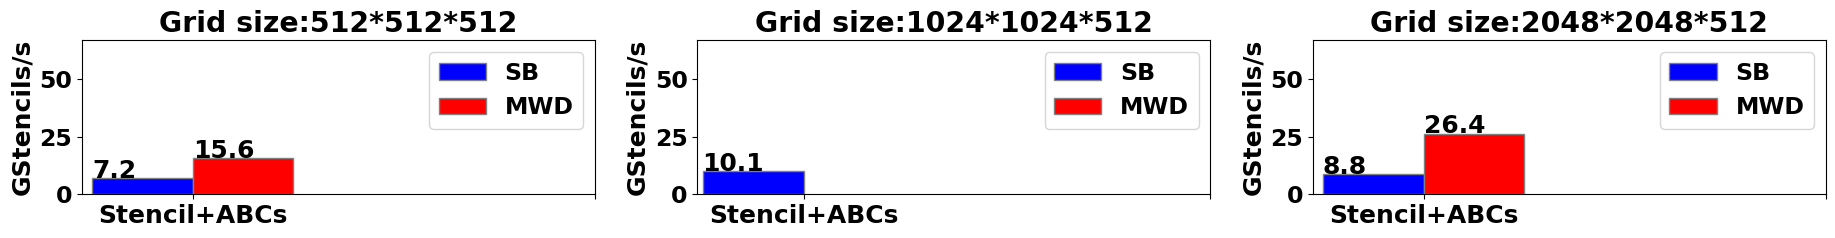

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


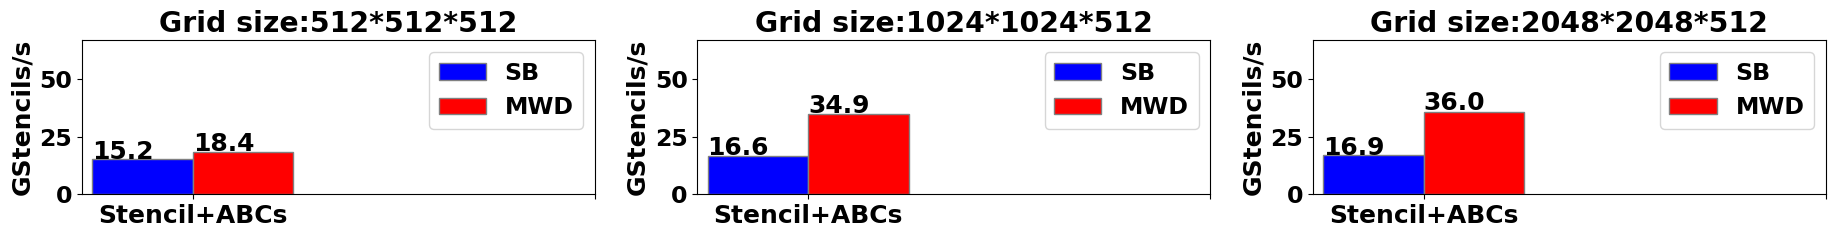

In [44]:
root_folder='./grid_perf/kanary/test1'
###################################################################################################################
order='_1st'
save_paths=['../performances/Milan_7713_1st_grids_gstencils.pdf',
            '../performances/Milan_7713_1st_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/Milan_7713_2nd_grids_gstencils.pdf',
            '../performances/Milan_7713_2nd_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################
aa=1

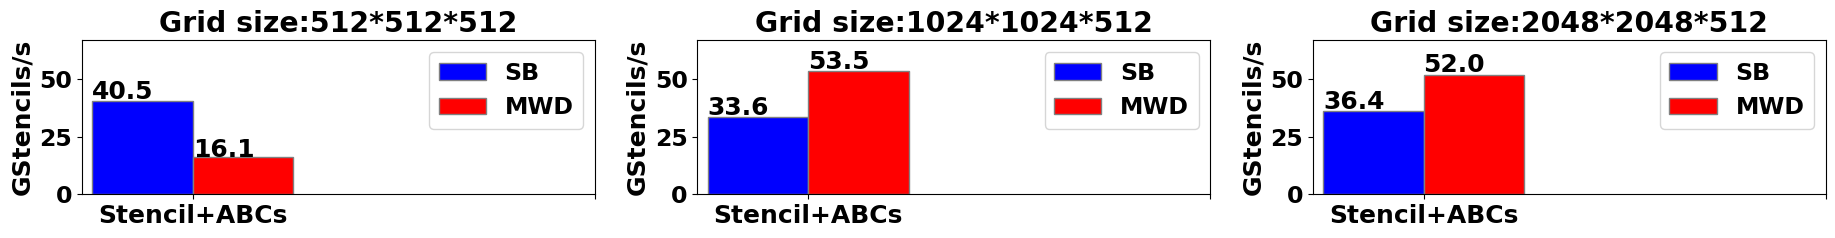

In [45]:
root_folder='./grid_perf/sh3_genoa'
###################################################################################################################
order='_1st'
save_paths=['../performances/sh3_genoa_1st_grids_gstencils.pdf',
            '../performances/sh3_genoa_1st_grids_gstencils.png']
# plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/sh3_genoa_2nd_grids_gstencils.pdf',
            '../performances/sh3_genoa_2nd_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################
aa=1

## Plot performance for grids, Sh3. better SB 2nd order

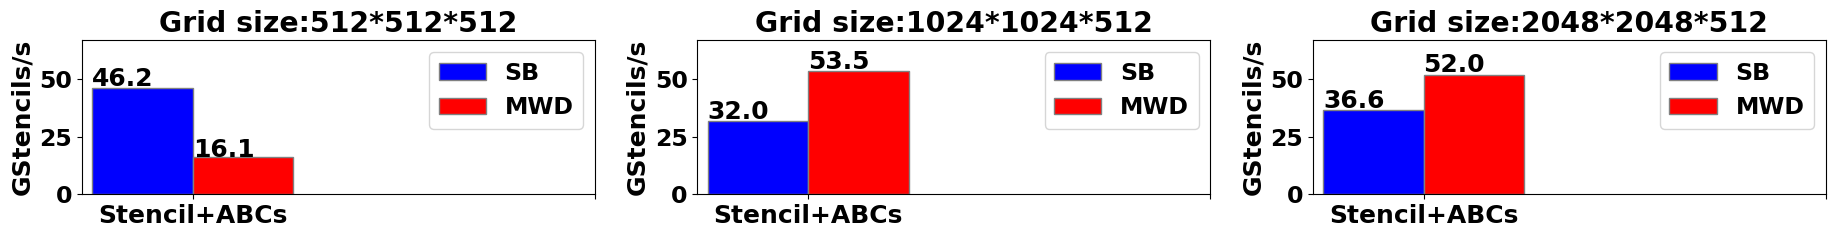

In [46]:
root_folder='./grid_perf/sh3_genoa_v2'
###################################################################################################################
order='_1st'
save_paths=['../performances/sh3_genoa_1st_grids_gstencils.pdf',
            '../performances/sh3_genoa_1st_grids_gstencils.png']
# plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/sh3_genoa_2nd_grids_gstencils.pdf',
            '../performances/sh3_genoa_2nd_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################

## Plot performance for grids, Sh3. wave_update_fields_block_bis

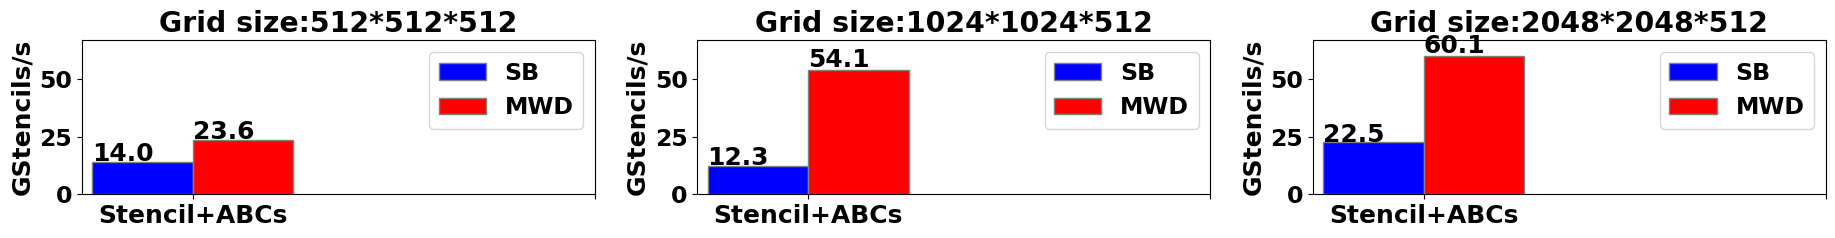

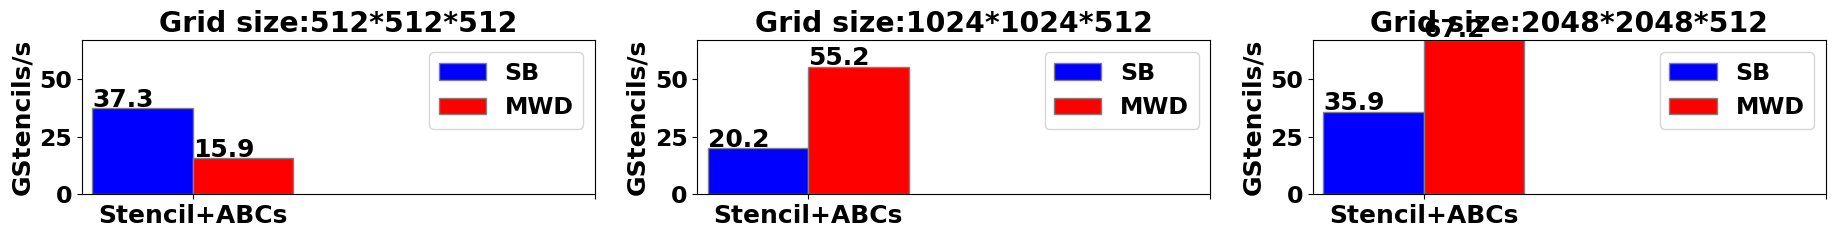

In [49]:
root_folder='./grid_perf/sh3_genoa_v3'
###################################################################################################################
order='_1st'
save_paths=['../performances/sh3_genoa_1st_grids_gstencils.pdf',
            '../performances/sh3_genoa_1st_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/sh3_genoa_2nd_grids_gstencils.pdf',
            '../performances/sh3_genoa_2nd_grids_gstencils.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################

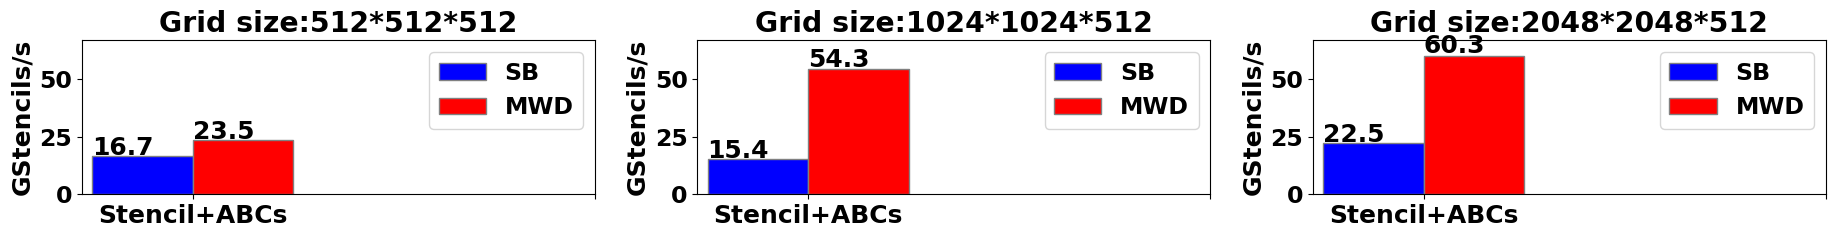

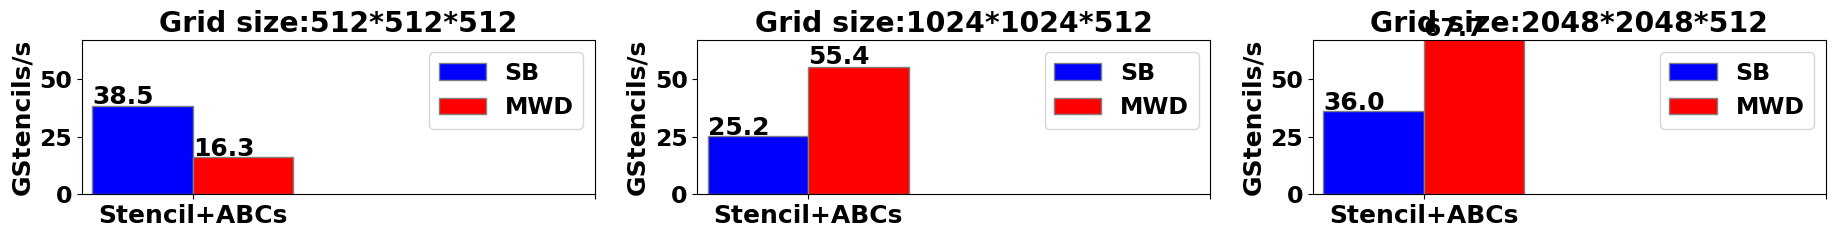

In [54]:
# root_folder='./grid_perf/sh3_genoa_v3'
root_folder='/media/plotnips/sdd1/Dropbox/Apps/download_to_laptop/sh3_genoa/test1_better/test1/'
###################################################################################################################
order='_1st'
save_paths=['../performances/sh3_genoa_1st_grids_gstencils2.pdf',
            '../performances/sh3_genoa_1st_grids_gstencils2.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/sh3_genoa_2nd_grids_gstencils2.pdf',
            '../performances/sh3_genoa_2nd_grids_gstencils2.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################

## 5 th April

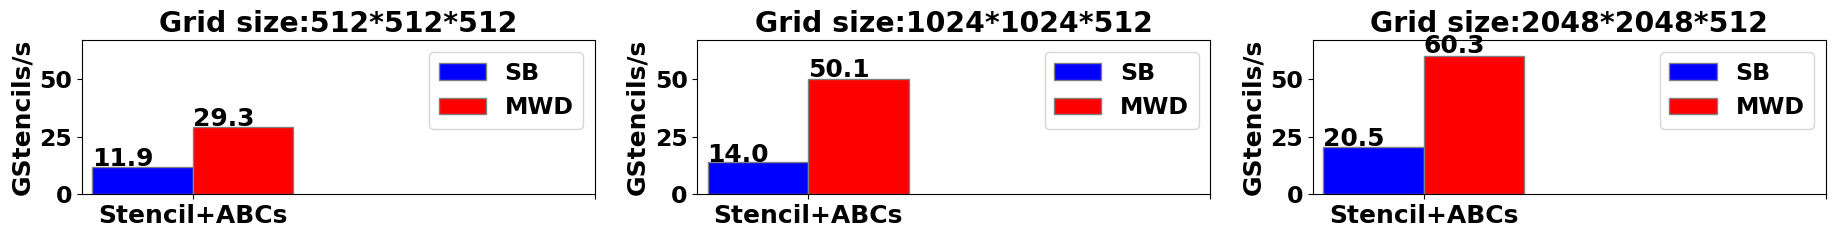

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


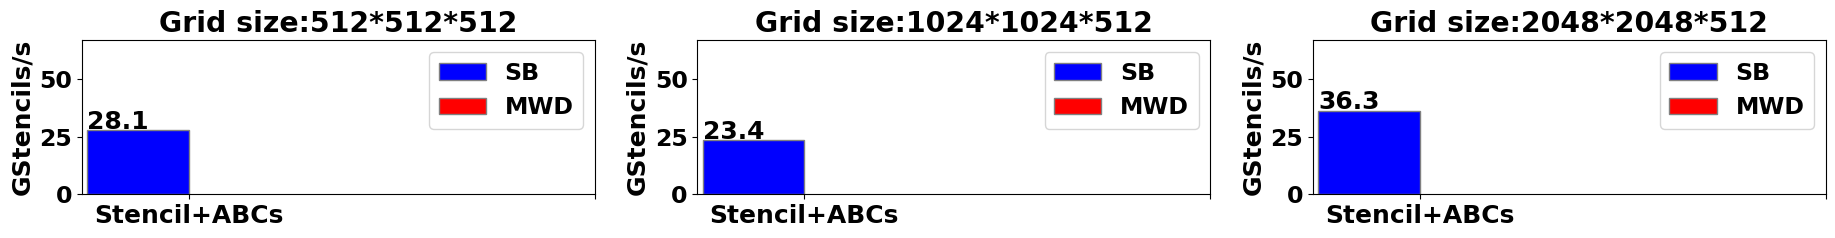

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


In [58]:
# root_folder='./grid_perf/sh3_genoa_v3'
root_folder='/media/plotnips/sdd1/Dropbox/Apps/download_to_laptop/sh3_genoa/2test'
###################################################################################################################
order='_1st'
save_paths=['../performances/sh3_genoa_1st_grids_gstencils2.pdf',
            '../performances/sh3_genoa_1st_grids_gstencils2.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 1st order results',metric='gstencils')
###################################################################################################################
order='_2nd'
save_paths=['../performances/sh3_genoa_2nd_grids_gstencils2.pdf',
            '../performances/sh3_genoa_2nd_grids_gstencils2.png']
plot_perf(save_paths,root_folder,order,grids,title_milanx+'\n 2nd order results',metric='gstencils')
# ###################################################################################################################